In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

ALPHA = 0.05
UNITS = "ug/dL"

cal_aq = {
    "conc_o": np.array([0, 5, 10, 18], dtype=float),
    "abs": np.array([0.00382, 0.12602, 0.27745, 0.45675], dtype=float),
}

cal_mod = {
    "conc_o": np.array([0, 3, 5, 7], dtype=float),
    "abs": np.array([0.08470, 0.3302, 0.43177, 0.50105], dtype=float),
}

samples_abs = {
    "id": np.arange(1, 21),
    "abs": np.array([
        0.21526, 0.21275, 0.22236, 0.20272, 0.22286,
        0.20545, 0.20621, 0.15814, 0.16339, 0.18416,
        0.17103, 0.15464, 0.15753, 0.13669, 0.15961,
        0.18964, 0.15723, 0.18073, 0.16712, 0.19304,
    ], dtype=float),
}

assert len(samples_abs["id"]) == len(samples_abs["abs"])


<frozen importlib._bootstrap>:491: Warning: Numpy built with MINGW-W64 on Windows 64 bits is experimental, and only available for 
testing. You are advised not to use it for production. 

CRASHES ARE TO BE EXPECTED - PLEASE REPORT THEM TO NUMPY DEVELOPERS


In [2]:
def fit_calibration(concentration, absorbance, name):
    """Ajusta Abs = intercepto + pendiente * concentracion."""
    x = np.asarray(concentration, dtype=float)
    y = np.asarray(absorbance, dtype=float)

    if len(x) != len(y) or len(x) < 3:
        raise ValueError("La concentracion y la absorbancia deben tener al menos 3 pares.")
    if np.unique(x).size < 2:
        raise ValueError("La concentracion debe contener al menos dos valores distintos.")

    model = sm.OLS(y, sm.add_constant(x)).fit()
    ci = model.conf_int(alpha=ALPHA)
    residuals = model.resid

    return {
        "name": name,
        "model": model,
        "intercept": float(model.params[0]),
        "slope": float(model.params[1]),
        "r2": float(model.rsquared),
        "r2_adj": float(model.rsquared_adj),
        "rmse": float(np.sqrt(np.mean(residuals ** 2))),
        "syx": float(np.sqrt(np.sum(residuals ** 2) / model.df_resid)),
        "se_intercept": float(model.bse[0]),
        "se_slope": float(model.bse[1]),
        "p_intercept": float(model.pvalues[0]),
        "p_slope": float(model.pvalues[1]),
        "ci_intercept": tuple(ci[0]),
        "ci_slope": tuple(ci[1]),
    }


def predict_absorbance(result, concentration):
    """Predice absorbancia a partir de una concentracion."""
    return result["intercept"] + result["slope"] * np.asarray(concentration, dtype=float)


def inverse_calibration(result, absorbance):
    """Invierte una recta como concentracion = (Abs - intercepto) / pendiente."""
    if result["slope"] == 0:
        raise ZeroDivisionError("La pendiente de la calibracion no puede ser cero.")
    return (np.asarray(absorbance, dtype=float) - result["intercept"]) / result["slope"]


def standard_addition_concentration(result, dilution_factor=1.0):
    """Calcula la concentracion por el corte de la recta con el eje X."""
    if result["slope"] == 0:
        raise ZeroDivisionError("La pendiente no puede ser cero.")

    x_intercept = -result["intercept"] / result["slope"]
    return {
        "x_intercept": float(x_intercept),
        "concentration": float(abs(x_intercept) * dilution_factor),
    }


calibration_aq = fit_calibration(
    cal_aq["conc_o"], cal_aq["abs"], "Calibracion acuosa"
)
calibration_mod = fit_calibration(
    cal_mod["conc_o"], cal_mod["abs"], "Adicion estandar / sangre"
)

standard_addition_result = standard_addition_concentration(calibration_mod)
print(f"Curvas ajustadas: {calibration_aq['name']} y {calibration_mod['name']}")
print(
    f"Concentracion de sangre por adicion estandar: "
    f"{standard_addition_result['concentration']:.4f} {UNITS}"
)


Curvas ajustadas: Calibracion acuosa y Adicion estandar / sangre
Concentracion de sangre por adicion estandar: 1.8730 ug/dL


In [3]:
def regression_statistics(result):
    return pd.Series({
        "ecuacion": (
            f"Abs = {result['intercept']:.6f} "
            f"+ {result['slope']:.6f} * Conc"
        ),
        "intercepto": result["intercept"],
        "pendiente": result["slope"],
        "SE_intercepto": result["se_intercept"],
        "SE_pendiente": result["se_slope"],
        "p_intercepto": result["p_intercept"],
        "p_pendiente": result["p_slope"],
        "R2": result["r2"],
        "R2_ajustado": result["r2_adj"],
        "RMSE": result["rmse"],
        "Sy_x": result["syx"],
        "IC95_intercepto": str(tuple(round(v, 6) for v in result["ci_intercept"])),
        "IC95_pendiente": str(tuple(round(v, 6) for v in result["ci_slope"])),
    })

regression_table = pd.DataFrame({
    calibration_aq["name"]: regression_statistics(calibration_aq),
    calibration_mod["name"]: regression_statistics(calibration_mod),
})

regression_table

,Calibracion acuosa,Adicion estandar / sangre
ecuacion,Abs = 0.006072 + 0.025447 * Conc,Abs = 0.112231 + 0.059920 * Conc
intercepto,0.006072,0.112231
pendiente,0.025447,0.05992
SE_intercepto,0.011247,0.037122
SE_pendiente,0.001062,0.008149
p_intercepto,0.643363,0.094202
p_pendiente,0.001736,0.018
R2,0.996532,0.964325
R2_ajustado,0.994798,0.946487
RMSE,0.009979,0.029804


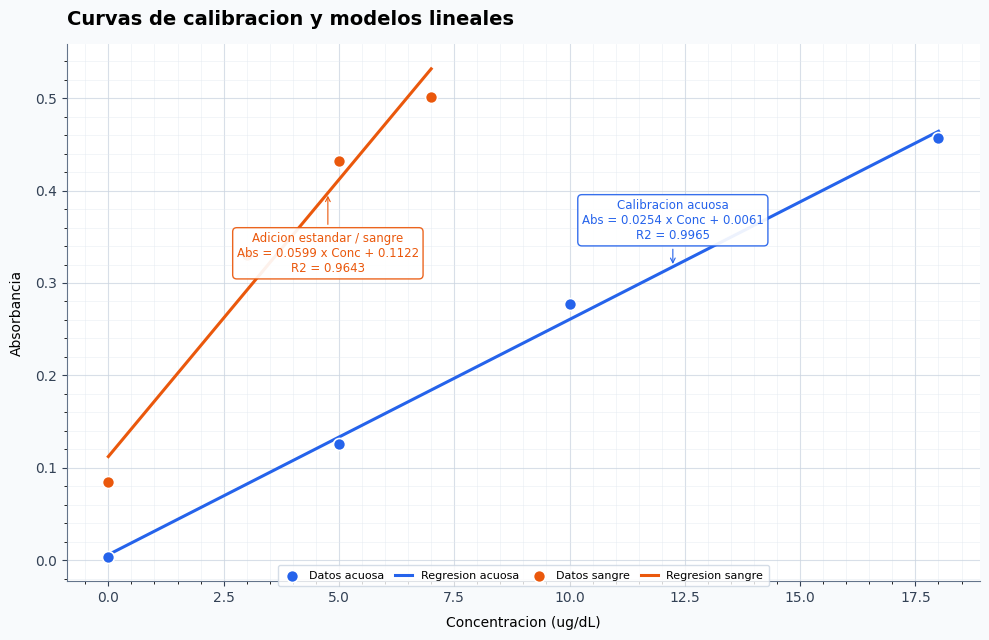

In [4]:
def equation_label(result):
    sign = "+" if result["intercept"] >= 0 else "-"
    intercept = abs(result["intercept"])
    return (
        f"{result['name']}\n"
        f"Abs = {result['slope']:.4f} x Conc {sign} {intercept:.4f}\n"
        f"R2 = {result['r2']:.4f}"
    )


def style_axes(ax):
    ax.set_axisbelow(True)
    ax.grid(True, which="major", color="#cbd5e1", linewidth=0.8, alpha=0.75)
    ax.grid(True, which="minor", color="#e2e8f0", linewidth=0.5, alpha=0.6)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#64748b")
    ax.spines["bottom"].set_color("#64748b")
    ax.tick_params(colors="#334155")


def plot_calibration_curves(cal_aq, cal_mod, result_aq, result_mod):
    curves = [
        (cal_aq, result_aq, "#2563eb", "acuosa"),
        (cal_mod, result_mod, "#ea580c", "sangre"),
    ]
    fig, ax = plt.subplots(figsize=(10, 6.5), facecolor="#f8fafc")
    ax.set_facecolor("#ffffff")

    for data, result, color, key in curves:
        x = np.asarray(data["conc_o"], dtype=float)
        y = np.asarray(data["abs"], dtype=float)
        x_line = np.linspace(x.min(), x.max(), 300)
        ax.scatter(
            x,
            y,
            color=color,
            edgecolor="white",
            linewidth=1.2,
            s=75,
            zorder=3,
            label=f"Datos {key}",
        )
        ax.plot(
            x_line,
            predict_absorbance(result, x_line),
            color=color,
            linewidth=2.2,
            label=f"Regresion {key}",
        )

        # La etiqueta se ancla a la propia curva, evitando invertir las ecuaciones.
        label_x = x.min() + 0.68 * (x.max() - x.min())
        label_y = float(predict_absorbance(result, label_x))
        vertical_offset = 18 if key == "acuosa" else -28
        ax.annotate(
            equation_label(result),
            xy=(label_x, label_y),
            xytext=(0, vertical_offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if vertical_offset > 0 else "top",
            color=color,
            fontsize=8.5,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": color,
                "alpha": 0.92,
            },
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "linewidth": 0.8,
            },
        )

    ax.set_xlabel(f"Concentracion ({UNITS})", labelpad=8)
    ax.set_ylabel("Absorbancia", labelpad=8)
    ax.set_title(
        "Curvas de calibracion y modelos lineales",
        loc="left",
        pad=14,
        fontsize=14,
        fontweight="bold",
    )
    style_axes(ax)
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#cbd5e1",
        fontsize=8,
        ncol=4,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        handlelength=1.5,
        columnspacing=1.0,
        borderpad=0.5,
    )
    fig.tight_layout()
    plt.show()
    return fig, ax


fig_curves, ax_curves = plot_calibration_curves(
    cal_aq, cal_mod, calibration_aq, calibration_mod
)

In [5]:
df_aq = pd.DataFrame({
    "concentracion": cal_aq["conc_o"],
    "absorbancia": cal_aq["abs"],
    "metodo": "Acuosa",
})
df_mod = pd.DataFrame({
    "concentracion": cal_mod["conc_o"],
    "absorbancia": cal_mod["abs"],
    "metodo": "Sangre",
})
df_ancova = pd.concat([df_aq, df_mod], ignore_index=True)

# La interaccion concentracion:metodo prueba si las pendientes son distintas.
ancova_interaction = smf.ols(
    "absorbancia ~ concentracion * metodo", data=df_ancova
).fit()
ancova_table = sm.stats.anova_lm(ancova_interaction, typ=2)
p_interaction = float(ancova_table.loc["concentracion:metodo", "PR(>F)"])

matrix_effect_percent = (
    calibration_mod["slope"] / calibration_aq["slope"] - 1
) * 100

print("ANCOVA con interaccion")
display(ancova_table)
print(f"\np de la interaccion: {p_interaction:.6g}")
print(f"Efecto matriz por pendientes: {matrix_effect_percent:.2f} %")
if p_interaction < ALPHA:
    print("Conclusion: las pendientes difieren significativamente.")
else:
    print("Conclusion: no se detecta diferencia significativa entre pendientes.")

ANCOVA con interaccion


,sum_sq,df,F,PR(>F)
metodo,0.109165,1.0,110.506964,0.000463
concentracion,0.182887,1.0,185.135171,0.000169
concentracion:metodo,0.027610,1.0,27.949311,0.006142
Residual,0.003951,4.0,NaN,NaN



p de la interaccion: 0.00614215
Efecto matriz por pendientes: 135.47 %
Conclusion: las pendientes difieren significativamente.


In [6]:
cal_mod_results = pd.DataFrame({
    "concentracion_anadida": cal_mod["conc_o"],
    "absorbancia_observada": cal_mod["abs"],
})
cal_mod_results["absorbancia_ajustada"] = predict_absorbance(
    calibration_mod, cal_mod["conc_o"]
)
cal_mod_results["residuo_absorbancia"] = (
    cal_mod_results["absorbancia_observada"]
    - cal_mod_results["absorbancia_ajustada"]
)

samples_results = pd.DataFrame({
    "id": samples_abs["id"],
    "absorbancia": samples_abs["abs"],
})

blood_concentration = standard_addition_result["concentration"]
samples_results["concentracion_adicion_estandar"] = blood_concentration

print("Concentracion de la muestra de sangre por adicion estandar:")
print(f"  Corte con X = {standard_addition_result['x_intercept']:.4f} {UNITS}")
print(f"  Concentracion estimada = {blood_concentration:.4f} {UNITS}")
print("\nPatrones usados para la recta:")
display(cal_mod_results)
print("\nMuestras de sangre: concentracion comun estimada por la recta:")
display(samples_results)


Concentracion de la muestra de sangre por adicion estandar:
  Corte con X = -1.8730 ug/dL
  Concentracion estimada = 1.8730 ug/dL

Patrones usados para la recta:


,concentracion_anadida,absorbancia_observada,absorbancia_ajustada,residuo_absorbancia
0,0.0,0.08470,0.112231,-0.027531
1,3.0,0.33020,0.291990,0.038210
2,5.0,0.43177,0.411830,0.019940
3,7.0,0.50105,0.531669,-0.030619



Muestras de sangre: concentracion comun estimada por la recta:


,id,absorbancia,concentracion_adicion_estandar
0,1,0.21526,1.873032
1,2,0.21275,1.873032
2,3,0.22236,1.873032
3,4,0.20272,1.873032
4,5,0.22286,1.873032
5,6,0.20545,1.873032
6,7,0.20621,1.873032
7,8,0.15814,1.873032
8,9,0.16339,1.873032
9,10,0.18416,1.873032


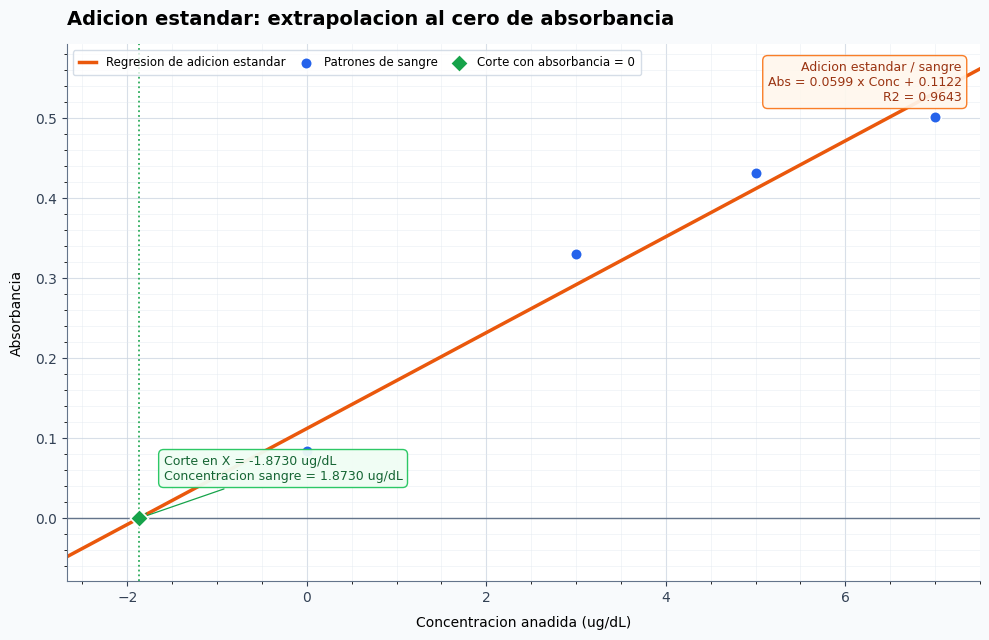

In [7]:
def plot_standard_addition(calibration_data, result, standard_addition):
    x_added = np.asarray(calibration_data["conc_o"], dtype=float)
    y_absorbance = np.asarray(calibration_data["abs"], dtype=float)
    x_intercept = standard_addition["x_intercept"]
    concentration = standard_addition["concentration"]

    x_min = min(x_intercept - 0.8, x_added.min() - 0.3)
    x_max = x_added.max() + 0.5
    x_line = np.linspace(x_min, x_max, 400)
    y_line = predict_absorbance(result, x_line)

    fig, ax = plt.subplots(figsize=(10, 6.5), facecolor="#f8fafc")
    ax.set_facecolor("#ffffff")
    ax.plot(
        x_line,
        y_line,
        color="#ea580c",
        linewidth=2.5,
        zorder=2,
        label="Regresion de adicion estandar",
    )
    ax.scatter(
        x_added,
        y_absorbance,
        color="#2563eb",
        edgecolor="white",
        linewidth=1.2,
        s=70,
        zorder=3,
        label="Patrones de sangre",
    )
    ax.scatter(
        x_intercept,
        0,
        color="#16a34a",
        edgecolor="white",
        linewidth=1.2,
        marker="D",
        s=85,
        zorder=5,
        label="Corte con absorbancia = 0",
    )
    ax.axhline(0, color="#64748b", linewidth=1.0)
    ax.axvline(
        x_intercept,
        color="#16a34a",
        linestyle=":",
        linewidth=1.3,
        alpha=0.9,
    )
    ax.annotate(
        (
            f"Corte en X = {x_intercept:.4f} {UNITS}\n"
            f"Concentracion sangre = {concentration:.4f} {UNITS}"
        ),
        xy=(x_intercept, 0),
        xytext=(18, 28),
        textcoords="offset points",
        color="#166534",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "#f0fdf4",
            "edgecolor": "#22c55e",
            "alpha": 0.95,
        },
        arrowprops={
            "arrowstyle": "->",
            "color": "#16a34a",
            "linewidth": 0.9,
        },
    )
    ax.text(
        0.98,
        0.97,
        equation_label(result),
        transform=ax.transAxes,
        ha="right",
        va="top",
        color="#9a3412",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "#fff7ed",
            "edgecolor": "#f97316",
            "alpha": 0.92,
        },
    )

    ax.set_xlim(x_min, x_max)
    ax.set_xlabel(f"Concentracion anadida ({UNITS})", labelpad=8)
    ax.set_ylabel("Absorbancia", labelpad=8)
    ax.set_title(
        "Adicion estandar: extrapolacion al cero de absorbancia",
        loc="left",
        pad=14,
        fontsize=14,
        fontweight="bold",
    )
    style_axes(ax)
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="#cbd5e1",
        fontsize=8.5,
        ncol=3,
        loc="upper left",
        handlelength=1.5,
        columnspacing=1.0,
        borderpad=0.5,
    )
    fig.tight_layout()
    plt.show()
    return fig, ax


fig_standard_addition, ax_standard_addition = plot_standard_addition(
    cal_mod, calibration_mod, standard_addition_result
)


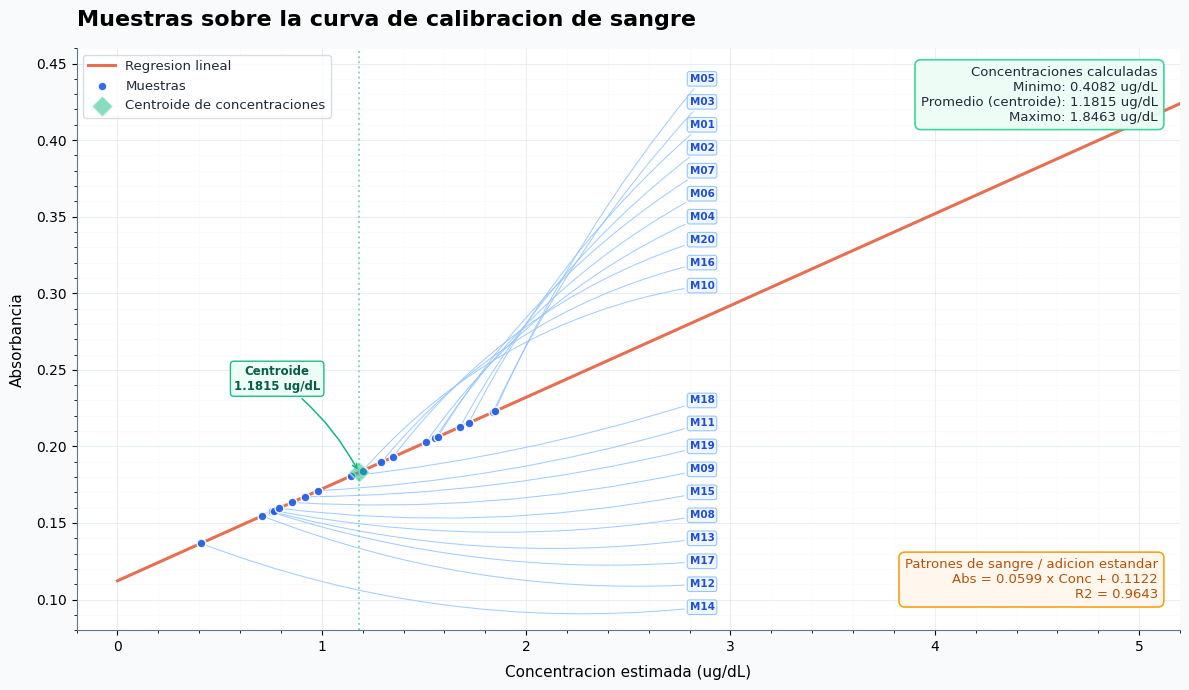

,id,absorbancia,concentracion_estimada
0,14,0.1367,0.4082
1,12,0.1546,0.7078
2,17,0.1572,0.7510
3,13,0.1575,0.7560
4,8,0.1581,0.7662
5,15,0.1596,0.7907
6,9,0.1634,0.8538
7,19,0.1671,0.9160
8,11,0.1710,0.9813
9,18,0.1807,1.1432


In [11]:
# Muestras interpoladas en la curva de calibracion
# Version optimizada: etiquetas claras, sin colisiones ni cruces sobre la recta

samples_conc_est = inverse_calibration(calibration_mod, samples_abs["abs"])
samples_df = pd.DataFrame({
    "id": samples_abs["id"],
    "absorbancia": samples_abs["abs"],
    "concentracion_estimada": samples_conc_est,
}).sort_values("concentracion_estimada").reset_index(drop=True)

x_reg = np.linspace(0, 5.2, 400)
y_reg = predict_absorbance(calibration_mod, x_reg)

centroid_x = float(samples_df["concentracion_estimada"].mean())
centroid_y = float(samples_df["absorbancia"].mean())

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#f8fafc")
ax.set_facecolor("#ffffff")
ax.set_axisbelow(True)
ax.grid(True, which="major", color="#e2e8f0", linewidth=0.8, alpha=0.7)
ax.grid(True, which="minor", color="#f1f5f9", linewidth=0.5, alpha=0.5)
ax.minorticks_on()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#64748b")
ax.spines["bottom"].set_color("#64748b")

# Regresion lineal
ax.plot(
    x_reg,
    y_reg,
    color="#e76f51",
    linewidth=2.2,
    zorder=2,
    label="Regresion lineal",
)

# Guia vertical del centroide
ax.axvline(
    centroid_x,
    color="#10b981",
    linestyle=":",
    linewidth=1.4,
    alpha=0.5,
    zorder=1,
)

# Muestras
ax.scatter(
    samples_df["concentracion_estimada"],
    samples_df["absorbancia"],
    s=40,
    color="#2563eb",
    edgecolor="white",
    linewidth=1.0,
    alpha=0.95,
    zorder=4,
    label="Muestras",
)

# Centroide de concentraciones (rombo verde)
ax.scatter(
    centroid_x,
    centroid_y,
    s=115,
    color="#10b981",
    edgecolor="white",
    linewidth=1.3,
    marker="D",
    zorder=5,
    label="Centroide de concentraciones",
    alpha=0.5
)

# Callout del centroide
ax.annotate(
    f"Centroide\n{centroid_x:.4f} ug/dL",
    (centroid_x, centroid_y),
    xytext=(centroid_x - 0.40, centroid_y + 0.052),
    textcoords="data",
    fontsize=8.5,
    fontweight="bold",
    color="#065f46",
    ha="center",
    va="bottom",
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "#ecfdf5",
        "edgecolor": "#10b981",
        "linewidth": 1.0,
        "alpha": 0.95,
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "#10b981",
        "linewidth": 1.1,
        "connectionstyle": "arc3,rad=-0.12",
    },
    zorder=6,
)

# Etiquetas de muestras en doble abanico limpio (sin cruces ni superposicion):
# - Mitad inferior: abanico curvado debajo de la recta de calibracion
# - Mitad superior: abanico curvado por encima de la recta de calibracion
n_half = len(samples_df) // 2
lower_samples = samples_df.iloc[:n_half].reset_index(drop=True)
upper_samples = samples_df.iloc[n_half:].reset_index(drop=True)

x_column = 2.80

# Abanico superior
y_upper = np.linspace(0.305, 0.440, len(upper_samples))
for i, row in upper_samples.iterrows():
    x0 = float(row["concentracion_estimada"])
    y0 = float(row["absorbancia"])
    ty = y_upper[i]
    label = f"M{int(row['id']):02d}"
    rad_val = 0.18 - 0.012 * i

    ax.annotate(
        label,
        (x0, y0),
        xytext=(x_column, ty),
        textcoords="data",
        fontsize=7.5,
        fontweight="semibold",
        color="#1d4ed8",
        ha="left",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "#eff6ff",
            "edgecolor": "#93c5fd",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": "#93c5fd",
            "linewidth": 0.75,
            "connectionstyle": f"arc3,rad={rad_val:.2f}",
            "alpha": 0.85,
        },
        zorder=3,
    )

# Abanico inferior
y_lower = np.linspace(0.095, 0.230, len(lower_samples))
for i, row in lower_samples.iterrows():
    x0 = float(row["concentracion_estimada"])
    y0 = float(row["absorbancia"])
    ty = y_lower[i]
    label = f"M{int(row['id']):02d}"
    rad_val = -0.12 + 0.008 * i

    ax.annotate(
        label,
        (x0, y0),
        xytext=(x_column, ty),
        textcoords="data",
        fontsize=7.5,
        fontweight="semibold",
        color="#1d4ed8",
        ha="left",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.22",
            "facecolor": "#eff6ff",
            "edgecolor": "#93c5fd",
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        arrowprops={
            "arrowstyle": "-",
            "color": "#93c5fd",
            "linewidth": 0.75,
            "connectionstyle": f"arc3,rad={rad_val:.2f}",
            "alpha": 0.85,
        },
        zorder=3,
    )

ax.set_xlim(-0.2, 5.2)
ax.set_ylim(0.08, 0.46)
ax.set_xlabel("Concentracion estimada (ug/dL)", fontsize=11, labelpad=8)
ax.set_ylabel("Absorbancia", fontsize=11, labelpad=8)
ax.set_title("Muestras sobre la curva de calibracion de sangre", fontsize=16, weight="bold", pad=16, loc="left")

legend = ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#cbd5e1",
    fontsize=9.5,
    fancybox=True,
)
for text in legend.get_texts():
    text.set_color("#1f2937")

# Resumen de concentraciones (esquina superior derecha)
summary = (
    "Concentraciones calculadas\n"
    f"Minimo: {samples_df['concentracion_estimada'].min():.4f} ug/dL\n"
    f"Promedio (centroide): {centroid_x:.4f} ug/dL\n"
    f"Maximo: {samples_df['concentracion_estimada'].max():.4f} ug/dL"
)
ax.text(
    0.98,
    0.97,
    summary,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9.5,
    color="#1f2937",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#ecfdf5",
        "edgecolor": "#34d399",
        "linewidth": 1.2,
        "alpha": 0.95,
    },
)

# Ecuacion de la calibracion (esquina inferior derecha)
ax.text(
    0.98,
    0.05,
    (
        "Patrones de sangre / adicion estandar\n"
        f"Abs = {calibration_mod['slope']:.4f} x Conc + {calibration_mod['intercept']:.4f}\n"
        f"R2 = {calibration_mod['r2']:.4f}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#b45309",
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#fff7ed",
        "edgecolor": "#f59e0b",
        "linewidth": 1.2,
        "alpha": 0.95,
    },
)

fig.tight_layout()
plt.show()

samples_df[["id", "absorbancia", "concentracion_estimada"]].round(4)
